<a href="https://colab.research.google.com/github/Vishwas1731/project-01-intern-/blob/main/internship_final_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import shap
import joblib

In [ ]:
df = pd.read_csv("/content/-HR-Employee-Attrition.csv")

print(df.head())
print(df.shape)
print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
df.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'],axis=1,inplace=True)

In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

In [ ]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Logistic Regression Accuracy:",
accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8775510204081632
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.15      0.25        39

    accuracy                           0.88       294
   macro avg       0.78      0.57      0.59       294
weighted avg       0.86      0.88      0.84       294



In [ ]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [ ]:
print("Decision Tree Accuracy:",
accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7857142857142857


In [ ]:
rf_model = RandomForestClassifier(n_estimators=200)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
print("Random Forest Accuracy:",
accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8775510204081632


In [ ]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [ ]:
print("Gradient Boosting Accuracy:",
accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.891156462585034


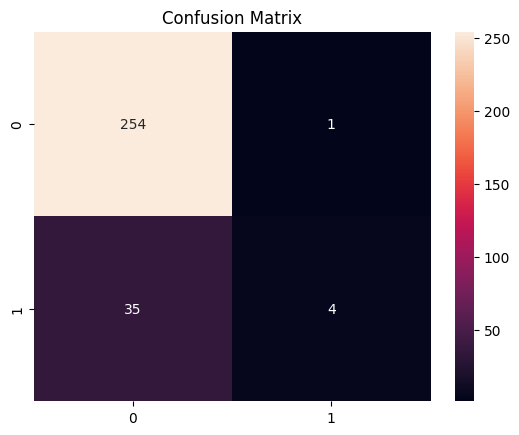

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

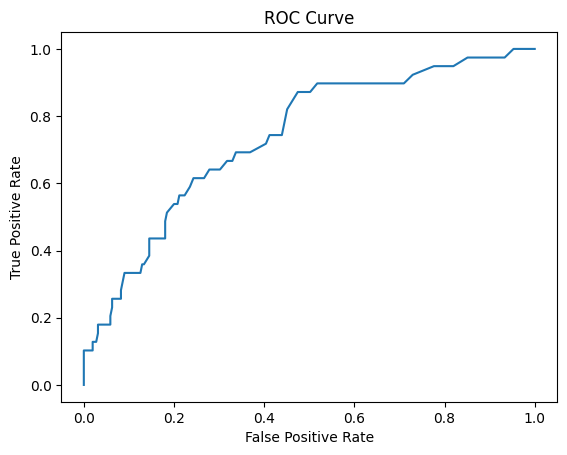

In [ ]:
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [ ]:
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.7379587732528909


In [ ]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({

'Feature': X.columns,

'Importance': importance

})

feature_importance = feature_importance.sort_values(
by='Importance', ascending=False)

print(feature_importance.head(10))

               Feature  Importance
15       MonthlyIncome    0.082024
18            OverTime    0.068282
0                  Age    0.057065
2            DailyRate    0.054496
23   TotalWorkingYears    0.051606
16         MonthlyRate    0.048144
9           HourlyRate    0.046158
4     DistanceFromHome    0.044514
26      YearsAtCompany    0.039758
17  NumCompaniesWorked    0.035906


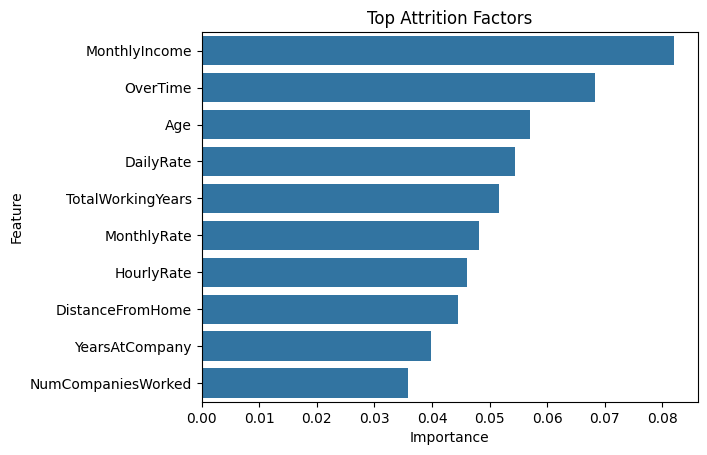

In [ ]:
sns.barplot(
x='Importance',
y='Feature',
data=feature_importance.head(10)
)

plt.title("Top Attrition Factors")

plt.show()

In [ ]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

 97%|=================== | 571/588 [00:25<00:00]       

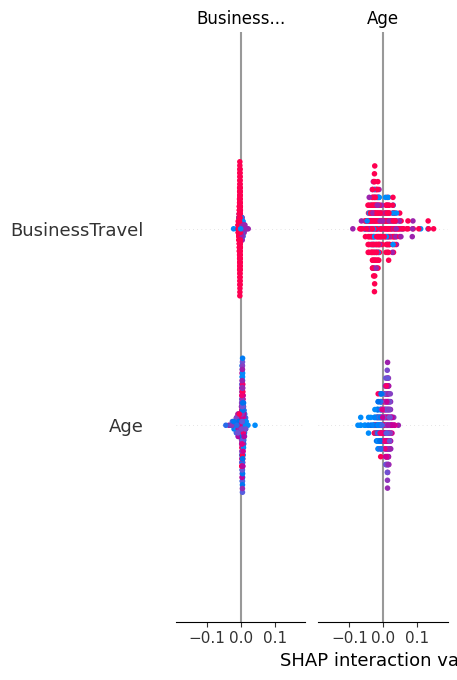

In [ ]:
import shap

explainer = shap.Explainer(rf_model, X_train)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
joblib.dump(rf_model, "attrition_model.pkl")

['attrition_model.pkl']

In [ ]:
new_employee = X.iloc[0:1]

prediction = rf_model.predict(new_employee)

probability = rf_model.predict_proba(new_employee)

print("Prediction:", prediction)

print("Attrition Probability:", probability)

Prediction: [1]
Attrition Probability: [[0.235 0.765]]


In [ ]:
risk_score = probability[0][1] * 100

print("Attrition Risk Score:", risk_score)

Attrition Risk Score: 76.5


In [ ]:
df.to_csv("processed_hr_data.csv", index=False)

In [ ]:
models = pd.DataFrame({

'Model': ['Logistic Regression','Decision Tree','Random Forest','Gradient Boosting'],

'Accuracy': [

accuracy_score(y_test, lr_pred),

accuracy_score(y_test, dt_pred),

accuracy_score(y_test, rf_pred),

accuracy_score(y_test, gb_pred)

]

})

print(models)

                 Model  Accuracy
0  Logistic Regression  0.877551
1        Decision Tree  0.785714
2        Random Forest  0.877551
3    Gradient Boosting  0.891156


In [ ]:
prob = model.predict_proba(X_test)[:,1]

risk_score = prob * 100

In [ ]:
def risk_level(score):
    if score > 70:
        return "High Risk"
    elif score > 40:
        return "Medium Risk"
    else:
        return "Low Risk"

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)

df['Cluster'] = kmeans.fit_predict(X)

In [ ]:
risk_levels = [risk_level(score) for score in risk_score]

In [ ]:
risk_df = pd.DataFrame({
    "Attrition Probability": prob,
    "Risk Score": risk_score,
    "Risk Level": risk_levels
})

print("\nEmployee Attrition Risk Scoring Results:")
print(risk_df.head(10))


Employee Attrition Risk Scoring Results:
   Attrition Probability  Risk Score   Risk Level
0                  0.170        17.0     Low Risk
1                  0.060         6.0     Low Risk
2                  0.405        40.5  Medium Risk
3                  0.035         3.5     Low Risk
4                  0.030         3.0     Low Risk
5                  0.395        39.5     Low Risk
6                  0.200        20.0     Low Risk
7                  0.120        12.0     Low Risk
8                  0.190        19.0     Low Risk
9                  0.295        29.5     Low Risk


In [ ]:
X_test["Attrition_Probability"] = prob
X_test["Risk_Score"] = risk_score
X_test["Risk_Level"] = risk_levels

print("\nDataset with Risk Score Added:")
print(X_test.head())


Dataset with Risk Score Added:
      Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
1041   28               2        866           2                 5          3   
184    53               2       1084           1                13          2   
1222   24               2        240           0                22          1   
67     45               2       1339           1                 7          3   
220    36               2       1396           1                 5          2   

      EducationField  EnvironmentSatisfaction  Gender  HourlyRate  ...  \
1041               3                        4       1          84  ...   
184                3                        4       0          57  ...   
1222               0                        4       1          58  ...   
67                 1                        2       1          59  ...   
220                1                        4       1          62  ...   

      TotalWorkingYears  TrainingTim

In [ ]:
print("\nRisk Level Distribution:")

print(pd.Series(risk_levels).value_counts())


Risk Level Distribution:
Low Risk       280
Medium Risk     14
Name: count, dtype: int64


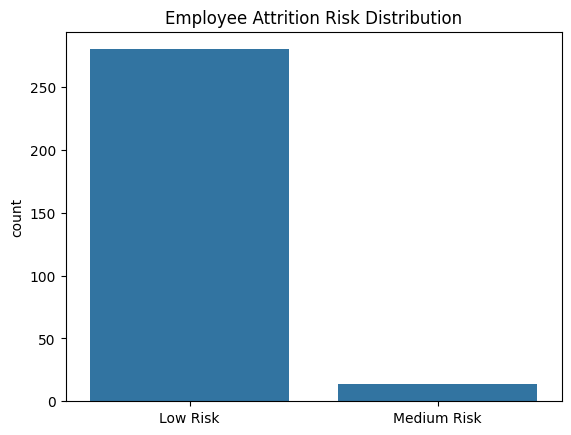

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=risk_levels)

plt.title("Employee Attrition Risk Distribution")

plt.show()

In [ ]:
def hr_action(score):
    if score > 70:
        return "Immediate HR Intervention"
    elif score > 40:
        return "Monitor Employee"
    else:
        return "No Action Needed"

risk_df["HR_Action"] = risk_df["Risk Score"].apply(hr_action)

print(risk_df.head())

   Attrition Probability  Risk Score   Risk Level         HR_Action
0                  0.170        17.0     Low Risk  No Action Needed
1                  0.060         6.0     Low Risk  No Action Needed
2                  0.405        40.5  Medium Risk  Monitor Employee
3                  0.035         3.5     Low Risk  No Action Needed
4                  0.030         3.0     Low Risk  No Action Needed


In [ ]:
def hr_action(score):
    if score > 70:
        return "Immediate HR Intervention"
    elif score > 40:
        return "Monitor Employee"
    else:
        return "No Action Needed"

risk_df["HR_Action"] = risk_df["Risk Score"].apply(hr_action)

print(risk_df.tail())

     Attrition Probability  Risk Score Risk Level         HR_Action
289                  0.090         9.0   Low Risk  No Action Needed
290                  0.110        11.0   Low Risk  No Action Needed
291                  0.190        19.0   Low Risk  No Action Needed
292                  0.235        23.5   Low Risk  No Action Needed
293                  0.115        11.5   Low Risk  No Action Needed
